## Import Libraries 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Read Data 

In [2]:
mall=pd.read_csv('Mall_Customers.csv')
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Analysis

In [3]:
mall.shape

(200, 5)

In [4]:
mall.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
mall.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [6]:
mall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
mall.describe(include='object')

,Gender
count,200
unique,2
top,Female
freq,112


In [9]:
mall.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Data Visualization

In [10]:
gender_counts=mall['Gender'].value_counts()
gender_counts

Gender
Female    112
Male       88
Name: count, dtype: int64

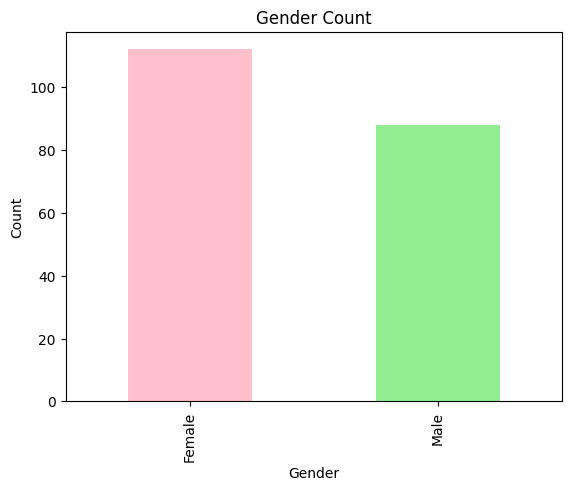

In [11]:
gender_counts.plot(kind='bar',color=['pink','lightgreen'])
plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [12]:
annual_rate=mall.groupby('Gender')['Annual Income (k$)'].mean()
annual_rate

Gender
Female    59.250000
Male      62.227273
Name: Annual Income (k$), dtype: float64

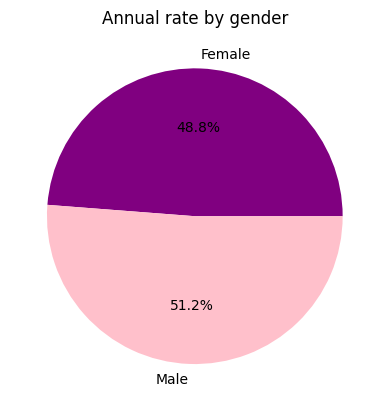

In [13]:
#annual rate by gender 
annual_rate.plot(kind='pie', autopct='%1.1f%%', colors=['purple', 'pink'])
plt.title('Annual rate by gender')
plt.ylabel('')
plt.show()

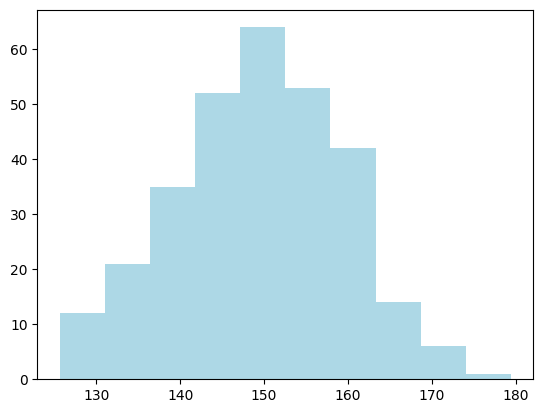

In [14]:
customers=np.random.normal(150,10,300)
plt.hist(customers , color='lightblue')
plt.show()

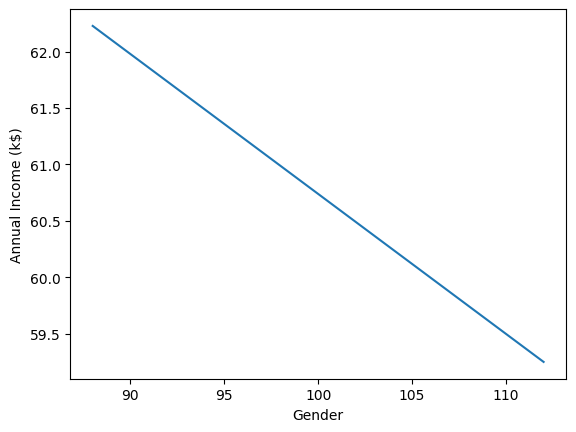

In [15]:
plt.plot(gender_counts,annual_rate)
plt.xlabel("Gender")
plt.ylabel("Annual Income (k$)")
plt.show()

<Axes: >

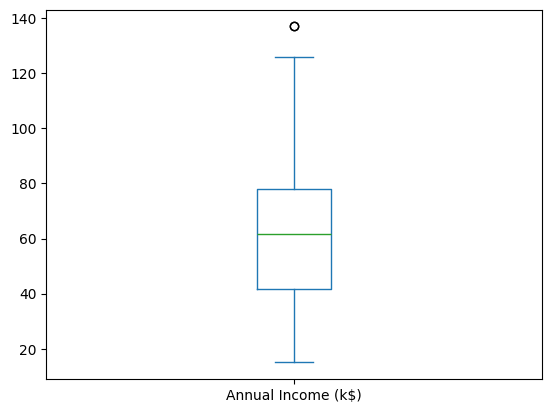

In [16]:
mall['Annual Income (k$)'].plot(kind='box')

In [17]:
qr1 = mall.describe()['Annual Income (k$)']['25%']
qr3 = mall.describe()['Annual Income (k$)']['75%']
IQR = qr3 - qr1

max = qr3 + 1.5 * IQR
min = qr1 - 1.5 * IQR

In [18]:
for i in mall.index:
    if mall.loc[i, 'Annual Income (k$)'] > max:
        mall.loc[i, 'Annual Income (k$)'] = max
    elif mall.loc[i, 'Annual Income (k$)'] < min:
        mall.loc[i, 'Annual Income (k$)'] = min

C:\Users\win 10\AppData\Local\Temp\ipykernel_17216\4034474111.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  mall.loc[i, 'Annual Income (k$)'] = max


<Axes: >

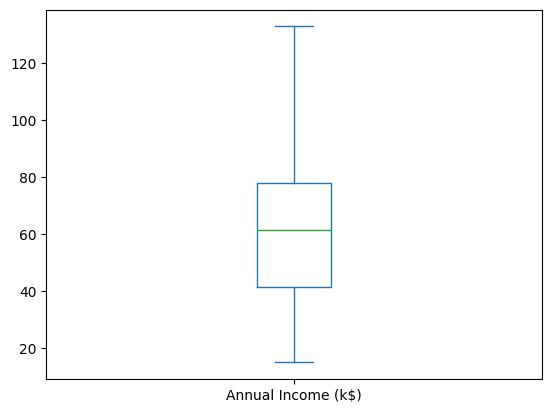

In [19]:
mall['Annual Income (k$)'].plot(kind='box')

## Data Preprocessing 

## Handling missing value

In [20]:
mean_age = mall['Age'].mean()
mall['Age'].fillna(mean_age, inplace=True)

C:\Users\win 10\AppData\Local\Temp\ipykernel_17216\2562078660.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mall['Age'].fillna(mean_age, inplace=True)


In [21]:
mall.dropna(subset=['Spending Score (1-100)'], inplace=True)

In [22]:
mall.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Duplicates 

In [23]:
mall.drop_duplicates(inplace=True)

## Encoding

In [24]:
mall.describe(include='object')

,Gender
count,200
unique,2
top,Female
freq,112


In [25]:
mall.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15.0,39
1,2,Male,21,15.0,81
2,3,Female,20,16.0,6
3,4,Female,23,16.0,77
4,5,Female,31,17.0,40
5,6,Female,22,17.0,76
6,7,Female,35,18.0,6
7,8,Female,23,18.0,94
8,9,Male,64,19.0,3
9,10,Female,30,19.0,72


In [26]:
mall['Gender'].replace({'male': 0, 'female': 1}, inplace=True)

C:\Users\win 10\AppData\Local\Temp\ipykernel_17216\1443174341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mall['Gender'].replace({'male': 0, 'female': 1}, inplace=True)


In [27]:
mall_encoded=df_encoded = pd.get_dummies(mall, columns=['Age'], drop_first=True)
mall_encoded.head()

,CustomerID,Gender,Annual Income (k$),Spending Score (1-100),Age_19,Age_20,Age_21,Age_22,Age_23,Age_24,...,Age_59,Age_60,Age_63,Age_64,Age_65,Age_66,Age_67,Age_68,Age_69,Age_70
0,1,Male,15.0,39,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,Male,15.0,81,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,Female,16.0,6,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,Female,16.0,77,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,5,Female,17.0,40,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Feature Engineering

In [28]:

mall_encoded['Age_pinned'] = pd.cut(mall['Age'], bins=[0,10,25,50,80], labels=[0, 1, 2, 3])
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15.0,39
1,2,Male,21,15.0,81
2,3,Female,20,16.0,6
3,4,Female,23,16.0,77
4,5,Female,31,17.0,40


In [29]:
mall_encoded['Age_pinned'] = mall_encoded['Age_pinned'].astype(int)

In [30]:
mall_encoded.dtypes

CustomerID                  int64
Gender                     object
Annual Income (k$)        float64
Spending Score (1-100)      int64
Age_19                       bool
Age_20                       bool
Age_21                       bool
Age_22                       bool
Age_23                       bool
Age_24                       bool
Age_25                       bool
Age_26                       bool
Age_27                       bool
Age_28                       bool
Age_29                       bool
Age_30                       bool
Age_31                       bool
Age_32                       bool
Age_33                       bool
Age_34                       bool
Age_35                       bool
Age_36                       bool
Age_37                       bool
Age_38                       bool
Age_39                       bool
Age_40                       bool
Age_41                       bool
Age_42                       bool
Age_43                       bool
Age_44        

In [31]:
mall_encoded.head()

,CustomerID,Gender,Annual Income (k$),Spending Score (1-100),Age_19,Age_20,Age_21,Age_22,Age_23,Age_24,...,Age_60,Age_63,Age_64,Age_65,Age_66,Age_67,Age_68,Age_69,Age_70,Age_pinned
0,1,Male,15.0,39,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
1,2,Male,15.0,81,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,1
2,3,Female,16.0,6,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
3,4,Female,16.0,77,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,1
4,5,Female,17.0,40,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2


## Normalization 

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
X = mall_encoded.drop(columns=['Gender'])
y = mall_encoded['Spending Score (1-100)']

In [34]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.fit_transform(X)

## Train Test Split

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=12)

## Model Development(ML Algorithm)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [38]:
mall_df = pd.read_csv("Mall_Customers.csv") 

In [39]:
print(mall_df.columns)  

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [40]:
mall_df = mall_df.iloc[:, :4]  

In [41]:
print(mall_df.head())  

   CustomerID  Gender  Age  Annual Income (k$)
0           1    Male   19                  15
1           2    Male   21                  15
2           3  Female   20                  16
3           4  Female   23                  16
4           5  Female   31                  17


In [42]:
x_feature = 'Annual Income (k$)'  
y_feature = 'Spending Score (1-100)' 

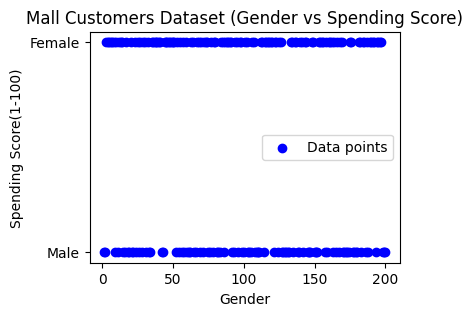

In [43]:
plt.figure(figsize=(4, 3))
plt.scatter(mall_df.iloc[:, 0], mall_df.iloc[:, 1], c='blue', label='Data points')
plt.xlabel('Gender')
plt.ylabel('Spending Score(1-100)')
plt.title('Mall Customers Dataset (Gender vs Spending Score)')
plt.legend()
plt.show()

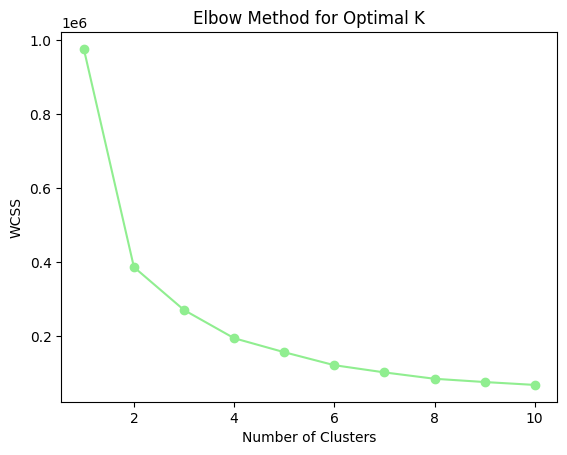

In [44]:
mall_df = pd.read_csv('Mall_Customers.csv')
mall_df_numeric = mall_df.select_dtypes(include=['number']).dropna()

wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(mall_df_numeric) 
    wcss.append(kmeans.inertia_)


# Plot the Elbow Method graph
plt.plot(cluster_range, wcss, marker='o', linestyle='-',color='lightgreen')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [45]:
mall_df = pd.read_csv('Mall_Customers.csv')

# Select only numeric columns
mall_df_numeric = mall_df.select_dtypes(include=['number']).dropna()

# Train KMeans model
model = KMeans(n_clusters=3, n_init=10)
model.fit(mall_df_numeric)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [46]:
# Add cluster labels to the original DataFrame
mall_df['Cluster'] = model.labels_

# Display first few rows
print(mall_df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


In [47]:
# Load the dataset
mall_df = pd.read_csv('Mall_Customers.csv')

# Select only numerical features for clustering
X = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


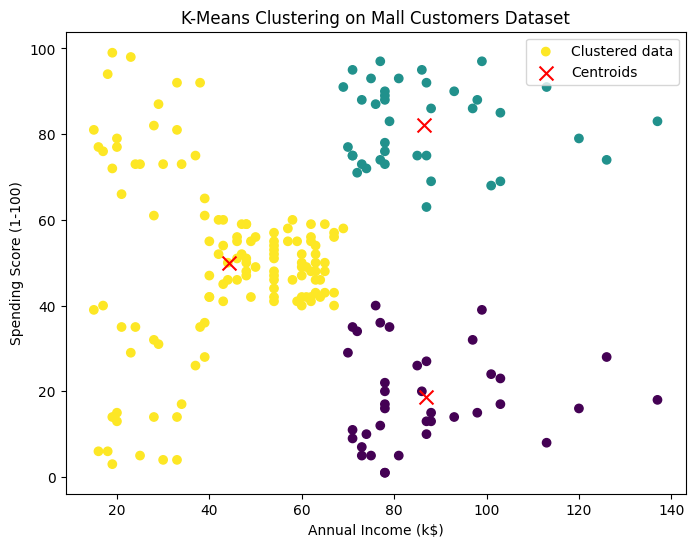

In [48]:
# Plot the clustered data
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=kmeans.labels_, cmap='viridis', label='Clustered data')

# Plot cluster centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=100, label='Centroids')

# Add labels and title
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering on Mall Customers Dataset')
plt.legend()
plt.show()


In [49]:
# Load the dataset
mall_df = pd.read_csv('Mall_Customers.csv')

# Select numerical features for clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall_df[features]

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans.fit(X)

# Create a DataFrame for centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)

# Print the centroids
print("Cluster Centroids:\n")
print(centroids)

Cluster Centroids:

   Annual Income (k$)  Spending Score (1-100)
0           87.000000               18.631579
1           86.538462               82.128205
2           44.154472               49.829268


## Model Evaluation

In [50]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf.score(x_test, y_test)

c:\Users\win 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\win 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


0.125

In [51]:
# TODO
y_pred = rf.predict(x_test)

In [52]:
from sklearn.metrics import classification_report
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         2
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         0
          34       0.00      0.00      0.00         1
          35       1.00      1.00      1.00         1
          40       0.00      0.00      0.00         1
          41       0.00      0.00      0.00         1
          42       0.50      1.00      0.67         1
          43       0.00      0.00      0.00         1
          46       0.00    

c:\Users\win 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\win 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\win 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\Users\win 10\AppData\

## Implementation

In [53]:
import joblib
import pandas as pd

In [54]:
joblib.dump(kmeans, 'mall_customers.joblob')

['mall_customers.joblob']

In [55]:
# TODO
df_encoded.columns

Index(['CustomerID', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Age_19', 'Age_20', 'Age_21', 'Age_22', 'Age_23', 'Age_24', 'Age_25',
       'Age_26', 'Age_27', 'Age_28', 'Age_29', 'Age_30', 'Age_31', 'Age_32',
       'Age_33', 'Age_34', 'Age_35', 'Age_36', 'Age_37', 'Age_38', 'Age_39',
       'Age_40', 'Age_41', 'Age_42', 'Age_43', 'Age_44', 'Age_45', 'Age_46',
       'Age_47', 'Age_48', 'Age_49', 'Age_50', 'Age_51', 'Age_52', 'Age_53',
       'Age_54', 'Age_55', 'Age_56', 'Age_57', 'Age_58', 'Age_59', 'Age_60',
       'Age_63', 'Age_64', 'Age_65', 'Age_66', 'Age_67', 'Age_68', 'Age_69',
       'Age_70', 'Age_pinned'],
      dtype='object')

In [56]:
X.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [57]:
inputs = {
    'Annual Income (k$)': int(input('Enter Annual Income (k$): ')), 
    'Spending Score (1-100)': int(input('Enter Spending Score (1-100): '))
}

mall_inputs = pd.DataFrame(inputs, index=[0])
mall_inputs

,Annual Income (k$),Spending Score (1-100)
0,15,95


In [58]:
kmeans.predict(mall_inputs)

array([2], dtype=int32)